# Compcor Comparison
- Metrics and setup taken from [the compcor library](https://github.com/IBM/comparing-corpora) and the [meme setup](https://github.com/IBM/meme) from ["Measuring the Measuring Tools" by Kour et al.](https://doi.org/10.18653/v1/2022.gem-1.35)

In [1]:
import time
import random
import torch
import os
import sklearn

import pandas as pd
import polars as pl
import numpy as np


import scipy
import statsmodels.api as sm
from statsmodels.formula.api import ols

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import compcor.corpus_metrics as corpus_metrics
from compcor.utils import Corpus
from compcor.text_tokenizer_embedder import STTokenizerEmbedder
from compcor.KSC import KSC

In [2]:
# Set random states.
def set_random_states(random_state):
    # Set various random seeds.
    np.random.seed(random_state)
    pl.set_random_seed(random_state)
    pd.core.common.random_state(random_state)
    random.seed(random_state)
    torch.manual_seed(random_state)
    torch.cuda.manual_seed_all(random_state)
    os.environ["PYTHONHASHSEED"] = str(random_state)
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
    return random_state

RANDOM_STATE = set_random_states(1618)

In [3]:
# ------------------ Metric Setup (experiment_config.py) ------------------
metrics = [
	corpus_metrics.chi_square_distance,
	# corpus_metrics.zipf_distance,
	# corpus_metrics.classifier_distance,
	# corpus_metrics.IRPR_distance,
	# corpus_metrics.fid_distance,
	# corpus_metrics.pr_distance,
	# corpus_metrics.dc_distance,
	# corpus_metrics.mauve_distance,
	# corpus_metrics.traditional_biber_distance,
	# corpus_metrics.zero_shot_biber_distance
]

metrics_names = [((str(dist).split()[1]).split('_')[0]).upper() for dist in metrics]
ksc_measures = ['Accuracy', 'Weighted Accuracy', 'Time', 'Monotonicity', 'Separability', 'Linearity']

# Helper function for getting metric-dependent data.
def get_metric_dependant_data(metric, corpus: Corpus):
	if metric in (corpus_metrics.zipf_distance, corpus_metrics.chi_square_distance):
		c = STTokenizerEmbedder().tokenize_sentences(corpus)
	elif metric in (corpus_metrics.traditional_biber_distance, corpus_metrics.traditional_biber_distance):
		c = corpus
	else:
		c = STTokenizerEmbedder().embed_sentences(corpus)
	return c

In [4]:
# ------------------ Loading and summarizing data functions. (utils.py) ------------------

# Helper function to load a labelled corpus.
def load_corpus(filename, sep=',', max_samples=np.inf):
	data = pd.read_csv(filename, sep=sep)
	data.drop(np.where(pd.isnull(data))[0], axis=0, inplace=True) # drop null data
	data = data.apply(lambda x: x.str.strip()) # strip extra whitespace
	data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index() # randomly shuffle dataset
	if not np.isinf(max_samples):
		data = data.head(max_samples) # get the number of samples required from the dataset
	sentences = data['text'].to_numpy() # convert sentences to numpy array
	return sentences

# Helper function to load data.
def load_data(max_samples=np.inf):
	clinc = load_corpus('./datasets/datasetsPrep/clinc150.csv', max_samples=max_samples)
	banking = load_corpus('./datasets/datasetsPrep/banking77.csv', max_samples=max_samples)
	atis = load_corpus('./datasets/datasetsPrep/atis.csv', sep=',',max_samples=max_samples)
	yahoo = load_corpus('./datasets/datasetsPrep/yahoo.csv', max_samples=max_samples)

	return clinc, banking, atis, yahoo

# Helper function to summarize results.
def summarize_results(metrics_measures_df):
	mu = metrics_measures_df.groupby(['metric']).mean()
	mu = mu.round(decimals=3)
	std = metrics_measures_df.groupby(['metric']).std()
	return mu, std

In [5]:
# ------------------ Functions to compute metric characteristics. (metric_characteristics.py) ------------------

# Helper function for metric monotonicity.
def metric_monotonicity(ells, distances):
	return scipy.stats.spearmanr(ells, distances).correlation

# Helper function for metric separability.
def metric_separability(ells, distances):
	df = pd.DataFrame(data=list(zip(ells, distances)), columns=['ell', 'distance'])
	model = ols('distance ~ C(ell)', data=df).fit()
	aov_table = sm.stats.anova_lm(model, typ=2)
	return anova_table(aov_table).loc['C(ell)', 'omega_sq']

# Helper function for anova table.
def anova_table(aov):
	aov['mean_sq'] = aov[:]['sum_sq'] / aov[:]['df']
	aov['eta_sq'] = aov.iloc[:-1]['sum_sq'] / sum(aov['sum_sq'])
	aov['omega_sq'] = (aov.iloc[:-1]['sum_sq'] - (aov.iloc[:-1]['df'] * aov['mean_sq'].iloc[-1])) / (
                sum(aov['sum_sq']) + aov['mean_sq'].iloc[-1])
	cols = ['sum_sq', 'df', 'mean_sq', 'F', 'PR(>F)', 'eta_sq', 'omega_sq']
	aov = aov[cols]
	return aov

# Helper function for metric linearity.
def metric_linearity(ells, distances):
	return scipy.stats.linregress(ells, y=distances).rvalue

# Helper function for robustness.
def metric_size_robustness(sizes, distances, true_distance):
	# Add epsilon to prevent zero divide. 
	epsilon = 1e-8
	return 1 - np.nansum(np.abs((distances - true_distance))) / ((true_distance + epsilon) * 10 * len(np.unique(sizes)))

# Helper function for metric imbalance robustness.
def metric_imbalance_robustness(sizes, comp_sizes, distances, true_distance):
	return 1 - sum(np.abs((distances - true_distance))) / (10 * len(np.unique(sizes)))

In [6]:
'''

# ------------------ Functions to compute Increasingly Fine-tuned Corpora experiments. (IFC_experiment.py) ------------------

SMALL_SIZE = 25
matplotlib.rc('font', size=SMALL_SIZE)
matplotlib.rc('axes', titlesize=SMALL_SIZE)

# Compute Increasingly Fine-tuned Corpora metrics.
def compute_IFC(metrics, metrics_names, reference_corpus, generated_corpora_path, rang,
                output_path, num_samples, repetitions=10):

    original = load_labeled_corpus(reference_corpus, max_samples=3000)

    distance_trend = []
    self_distance = []
    for i in rang:
        #sentences = utils.load_corpus(os.path.join(generated_corpora_path,'iteration_{}.txt'.format(i)), max_samples=3000)
        generated = load_labeled_corpus(os.path.join(generated_corpora_path ,'{}.tsv').format(i), max_samples=3000)
        for m,metric in enumerate(metrics):
            print(metric)
            generated_c = np.array(get_metric_dependant_data(metric, generated))
            original_c = np.array(get_metric_dependant_data(metric, original))
            for rep in range(repetitions):
                indices = random.sample(range(len(original_c)), num_samples)
                indices_generated = random.sample(range(len(generated_c)), num_samples)
                original_subset = original_c[indices].tolist()
                generated_subset = generated_c[indices_generated].tolist()
                distance_trend.append([i, metrics_names[m],rep, metric(original_subset,generated_subset)])

            #Estimate reference-reference distance
            indices = random.sample(range(len(original_c)), num_samples)
            original_subset1 = original_c[indices].tolist()
            indices = random.sample(range(len(original_c)), num_samples)
            original_subset2 = original_c[indices].tolist()

            self_distance.append([i, metrics_names[m], metric(original_subset1, original_subset2)])

    df_IFC_distance = pd.DataFrame(data=distance_trend, columns=['iteration', 'metric', 'rep', 'distance'])
    df_reference_self_distance = pd.DataFrame(data=self_distance, columns=['iteration', 'metric', 'distance'])

    df_IFC_distance.to_csv(path_or_buf=os.path.join(output_path, 'ifc_distance.csv'), index=False)
    df_reference_self_distance.to_csv(path_or_buf=os.path.join(output_path, 'df_reference_self_distance.csv'), index=False)

    return df_IFC_distance, df_reference_self_distance

# Plot Increasingly Fine-tuned Corpora metrics.
def plot_IFC(df_distance, df_self_distance):
    plt.style.use('seaborn-whitegrid')
    metrics_names = np.unique(df_distance['metric'])

    fig, ax = plt.subplots(1, len(metrics_names), figsize=(35, 5))
    for i, metric_name in enumerate(metrics_names):
        metric_df = df_distance[df_distance['metric'] == metric_name]

        sns.scatterplot(x='iteration', y='distance', data=metric_df, ax=ax[i], color='orange',  s=40)
        sns.regplot(x='iteration', y='distance', data=metric_df, ax=ax[i],
                    scatter=False, truncate=False, color='blue')
        self_metric_df = df_self_distance[df_self_distance['metric'] == metric_name]

        x_min_max = [np.min(self_metric_df['iteration']), np.max(self_metric_df['iteration'])]
        mean_self_distance = np.mean(self_metric_df['distance'])
        sns.lineplot(x=x_min_max, y=mean_self_distance, ax=ax[i], color='green', linewidth=2)

    [axi.set_title(metrics_names[i]) for i, axi in enumerate(ax)]
    [axi.set(xlabel=None) for axi in ax]
    [axi.set(ylabel=None) for axi in ax]

    plt.subplots_adjust(left=0.05,
                        bottom=0.1,
                        right=0.99,
                        top=0.9,
                        wspace=0.3,
                        hspace=0.4)

    plt.show()

# ISABEL HERE - PATHS NEED TO BE CHANGED IF USING BUT YOU HAVE NOT GENERATED DATA FOR THIS YET
reference_path = 'data/banking77_data.tsv' # or './data/news_data/news_data.tsv'
generated_path = 'data/banking77_generated' # or './data/news_data/generated_news_data/'
sampled_samples = 700 # or sampled_samples = 100
rang = range(1, 35, 1) # or rang = range(1, 75, 2)


df_distance, df_self_distance = compute_IFC(metrics,metrics_names,reference_path, generated_path,
                                            rang=rang,
                                            output_path=os.path.join('/outputCompcor/IFC','banking_77_new'),
                                            num_samples=sampled_samples)

plot_IFC(df_distance, df_self_distance)

'''

"\n\n# ------------------ Functions to compute Increasingly Fine-tuned Corpora experiments. (IFC_experiment.py) ------------------\n\nSMALL_SIZE = 25\nmatplotlib.rc('font', size=SMALL_SIZE)\nmatplotlib.rc('axes', titlesize=SMALL_SIZE)\n\n# Compute Increasingly Fine-tuned Corpora metrics.\ndef compute_IFC(metrics, metrics_names, reference_corpus, generated_corpora_path, rang,\n                output_path, num_samples, repetitions=10):\n\n    original = load_labeled_corpus(reference_corpus, max_samples=3000)\n\n    distance_trend = []\n    self_distance = []\n    for i in rang:\n        #sentences = utils.load_corpus(os.path.join(generated_corpora_path,'iteration_{}.txt'.format(i)), max_samples=3000)\n        generated = load_labeled_corpus(os.path.join(generated_corpora_path ,'{}.tsv').format(i), max_samples=3000)\n        for m,metric in enumerate(metrics):\n            print(metric)\n            generated_c = np.array(get_metric_dependant_data(metric, generated))\n            original

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0


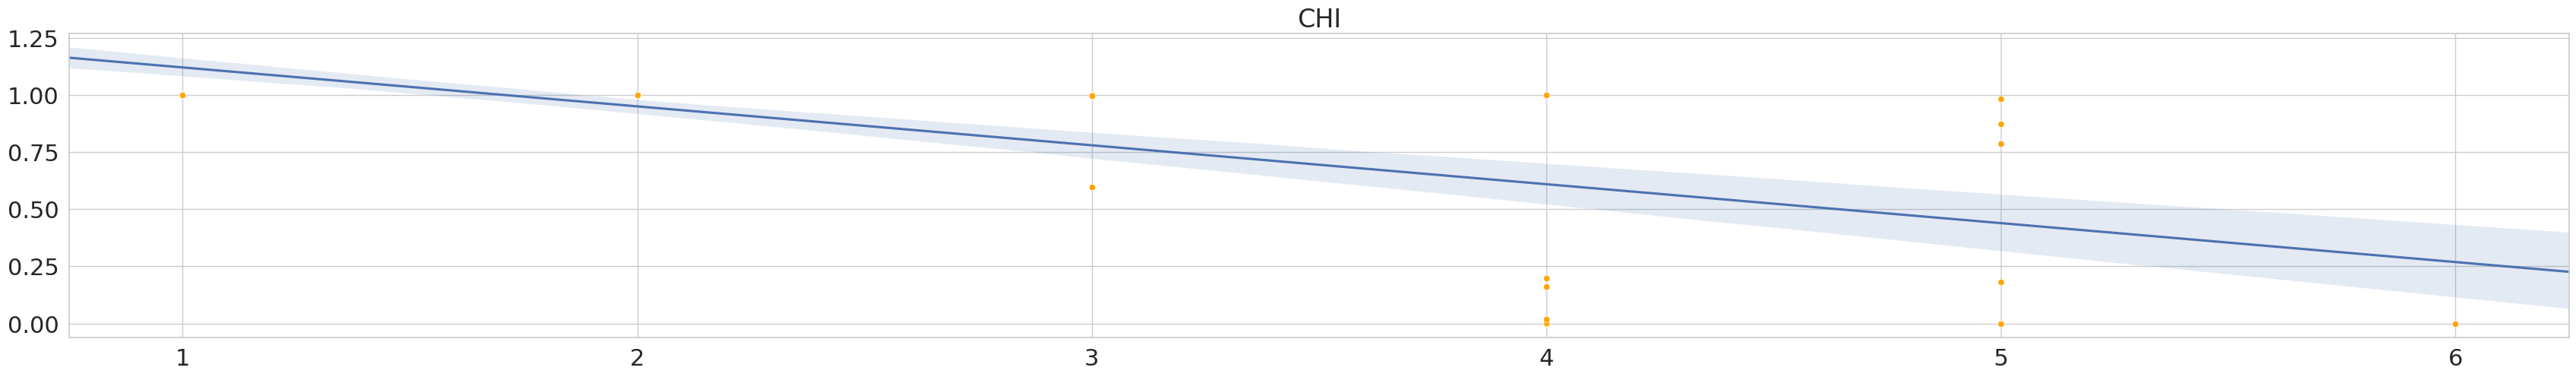

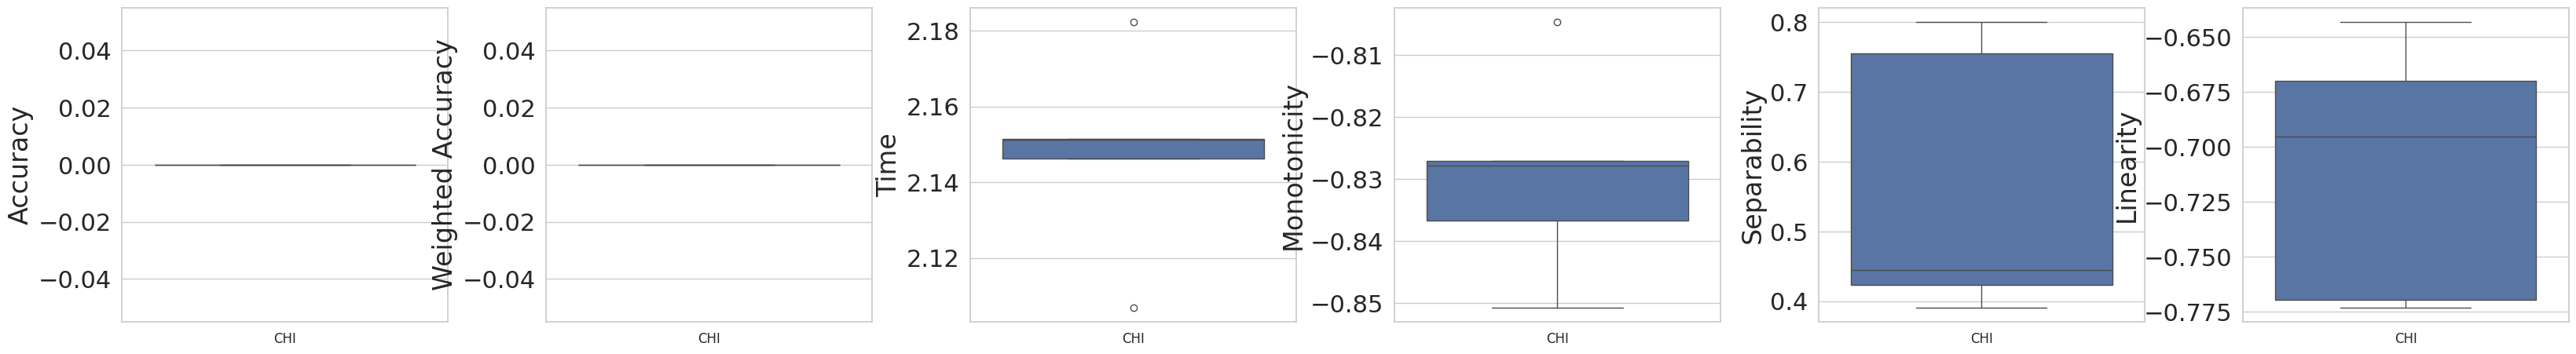

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 156
chi: KSC_Score: 0.0,Weighted KSC:0.0


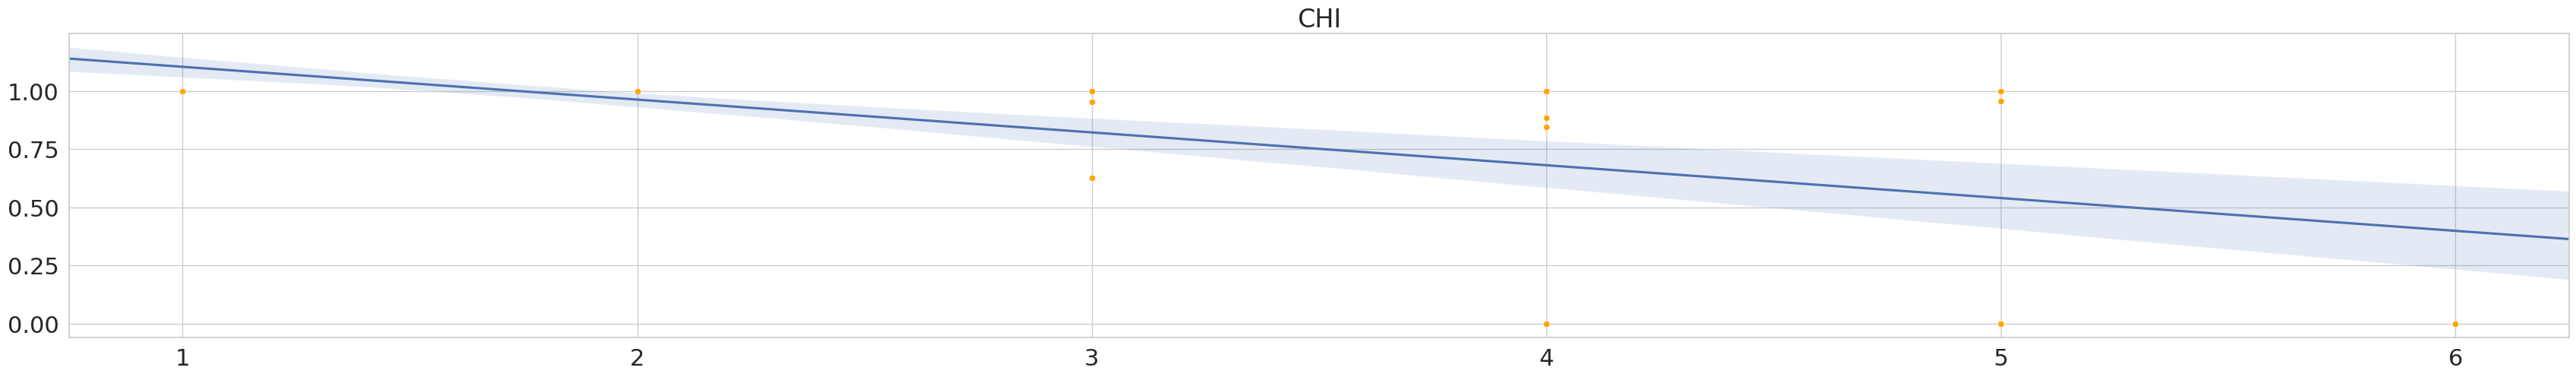

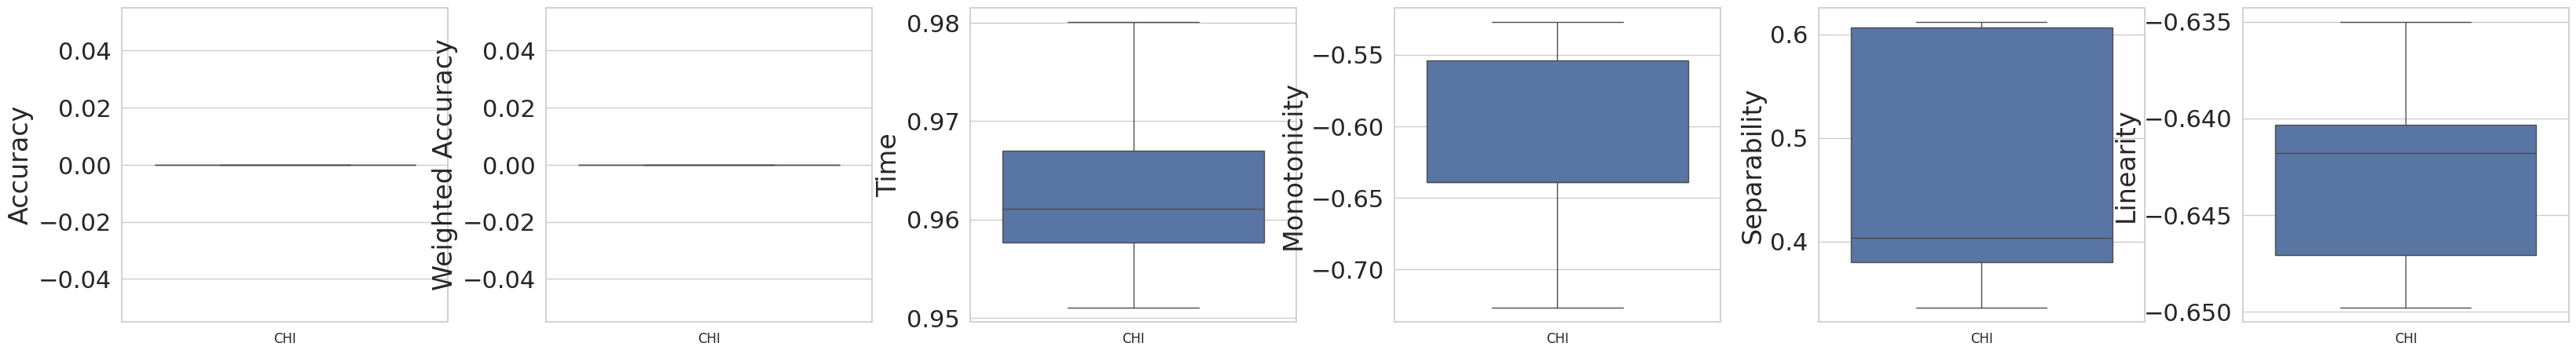

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Num judgments: 6053
chi: KSC_Score: 0.0016520733520568314,Weighted KSC:0.002896478812774713
Num judgments: 6053
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 6053
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 6053
chi: KSC_Score: 0.0,Weighted KSC:0.0
Num judgments: 6053
chi: KSC_Score: 0.0009912440112340988,Weighted KSC:0.0017378872876648277


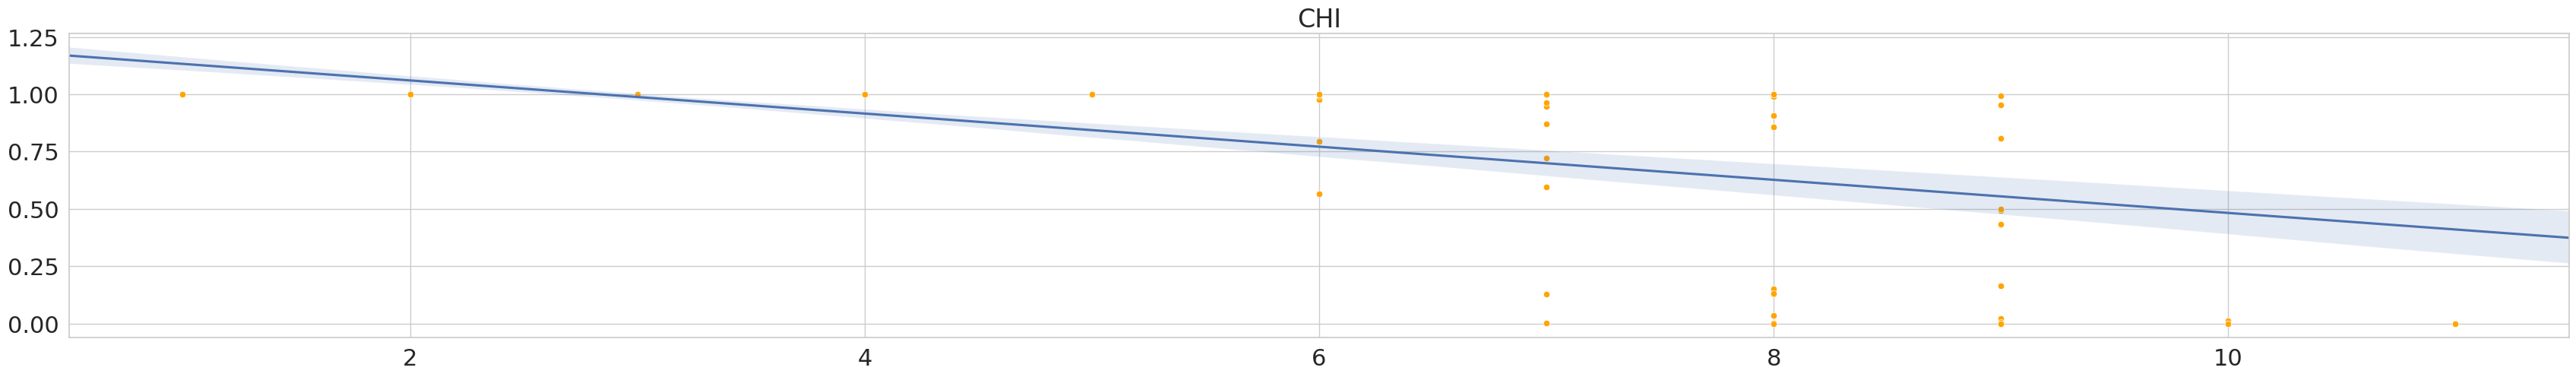

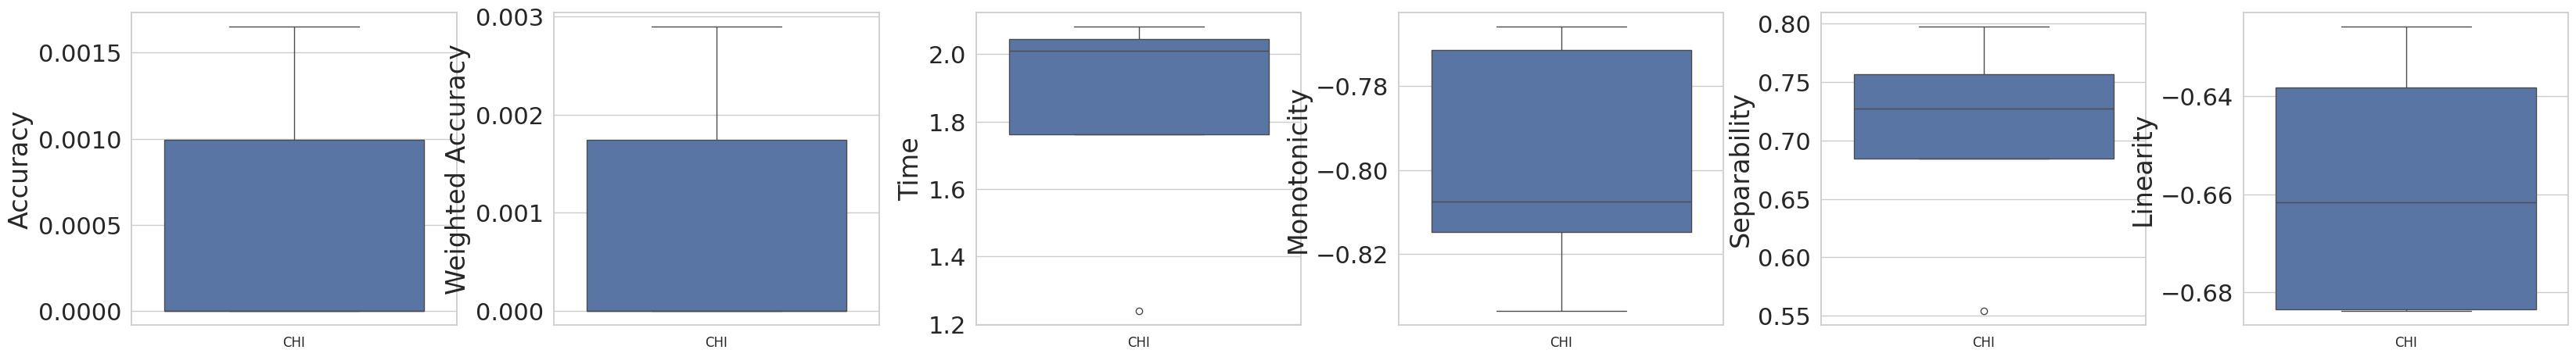

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Num judgments: 6053
chi: KSC_Score: 0.0004956220056170494,Weighted KSC:0.0008689436438324139
Num judgments: 6053
chi: KSC_Score: 0.00016520733520568312,Weighted KSC:0.0002896478812774713
Num judgments: 6053
chi: KSC_Score: 0.0006608293408227325,Weighted KSC:0.001158591525109885
Num judgments: 6053
chi: KSC_Score: 0.0018172806872625144,Weighted KSC:0.0031861266940521843
Num judgments: 6053
chi: KSC_Score: 0.0,Weighted KSC:0.0


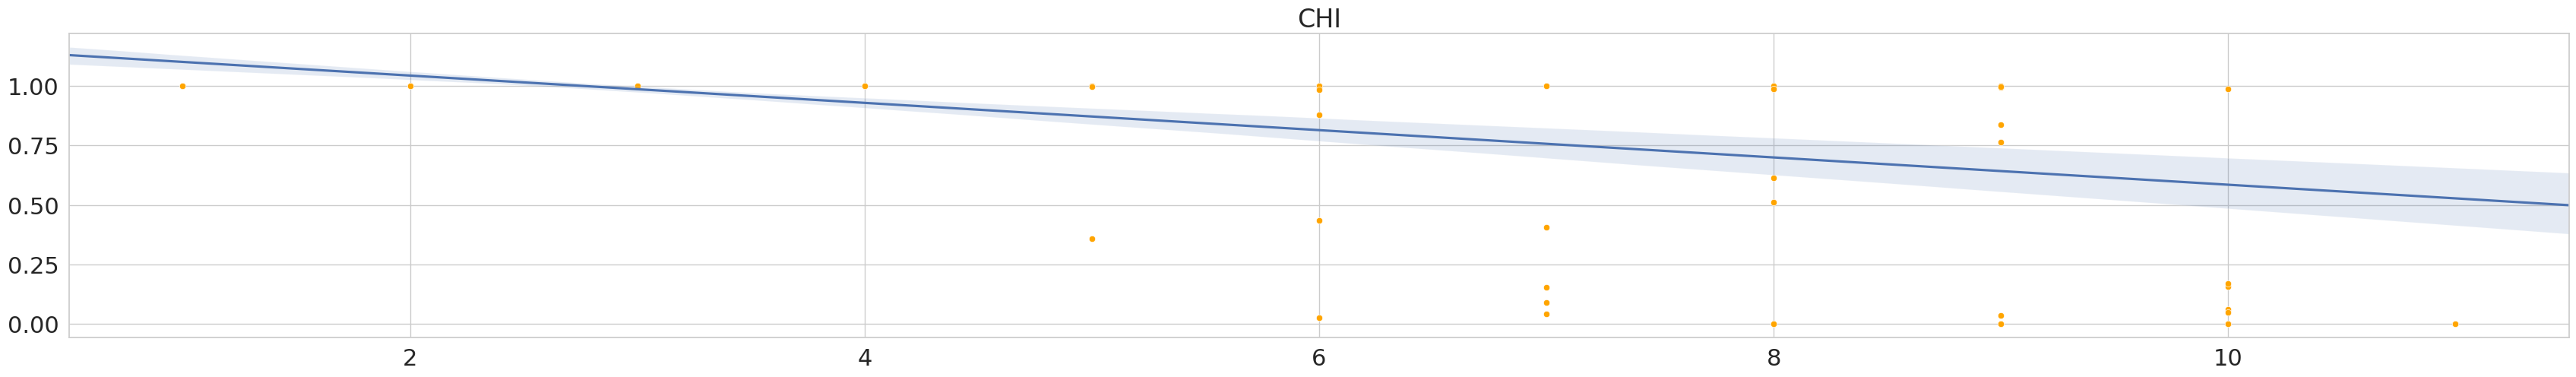

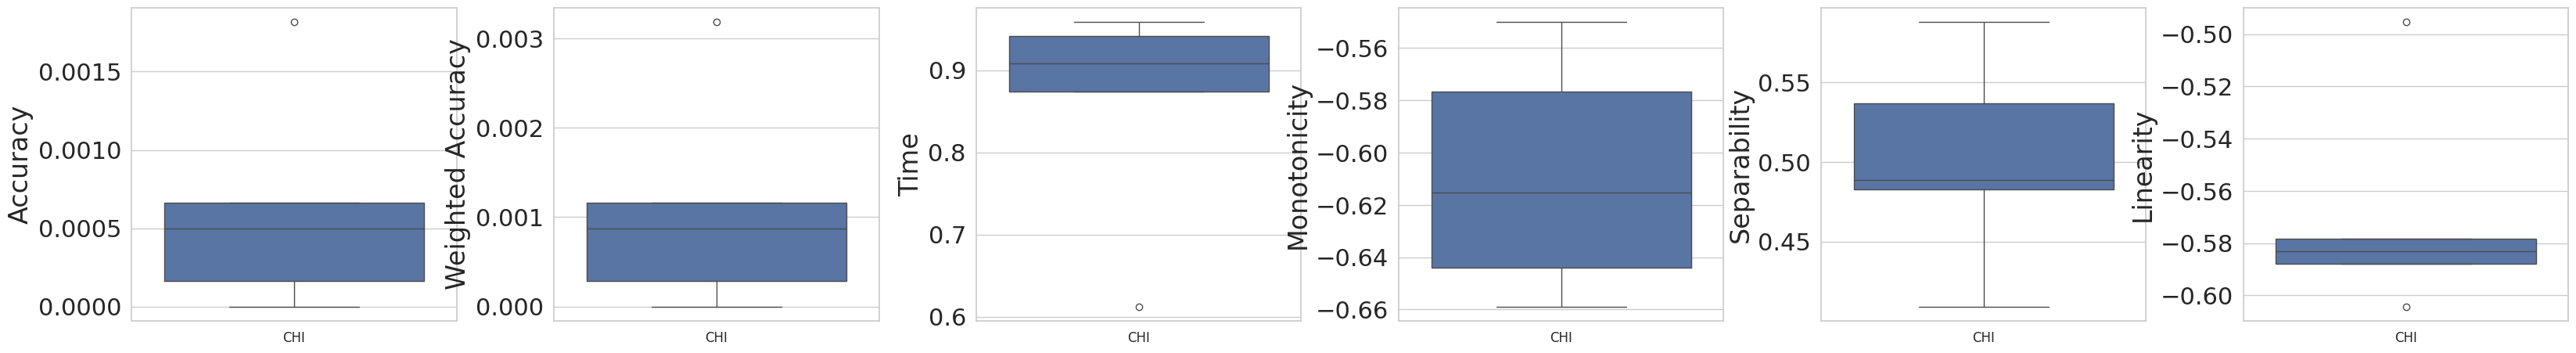

In [9]:
SMALL_SIZE = 15
matplotlib.rc('font', size=SMALL_SIZE)
matplotlib.rc('axes', titlesize=SMALL_SIZE)

sns.set_theme(style="whitegrid", font_scale=2)

def runKSC(metrics, metric_names, corpus1:Corpus, corpus2:Corpus, n=30, k=7, repetitions=5, output="ksc"):
	ksc_results = []
	distance_results = []

	for metric_idx, metric in enumerate(metrics):
		c1 = get_metric_dependant_data(metric, corpus1)
		c2 = get_metric_dependant_data(metric, corpus2)

		for rep in range(repetitions):

			distances_metric = []

			ksc = KSC._known_similarity_corpora(c1, c2, n=n, k=k, unique_samples_corpora=True)
			start = time.time()
			accuracy, weighted_accuracy, distance_stats = KSC.test_ksc(ksc, dist=metric)
			ksc_time = (time.time() - start) / len(distance_stats)

			distances_metric.append(
				np.vstack([[metric_names[metric_idx], rep, a, b, b - a, y] for (a, b, y) in distance_stats]))

			distances_metric = np.vstack(distances_metric)

			# normalize the score for a specific metric.
			distances_metric = np.append(distances_metric, sklearn.preprocessing.StandardScaler().fit_transform(
				distances_metric[:, 5].reshape(-1, 1)), axis=1)
			distance_results.extend(distances_metric)

			ells = distances_metric[:, 4].astype('float')
			ds_normalized = distances_metric[:, 6].astype('float')

			monotonicity = metric_monotonicity(ells, ds_normalized)
			separability = metric_separability(ells, ds_normalized)
			linearity = metric_linearity(ells, ds_normalized)
			ksc_results.append(
                [metric_names[metric_idx], accuracy, weighted_accuracy, ksc_time, monotonicity, separability, linearity])

	metrics_measures_df = pd.DataFrame(data=ksc_results, columns=['metric'] + ksc_measures)
	metrics_measures_df['Time'] = (1 / metrics_measures_df['Time'])/100

	all_distance_samples_df = pd.DataFrame(data=distance_results,
                                	columns=['metric', 'repetition', 'i', 'j', 'l', 'distance', 'distance_score'])
	all_distance_samples_df["l"] = pd.to_numeric(all_distance_samples_df["l"])
	all_distance_samples_df["distance"] = pd.to_numeric(all_distance_samples_df["distance"])
	all_distance_samples_df["distance_score"] = pd.to_numeric(all_distance_samples_df["distance_score"])
	metrics_measures_df.to_csv(path_or_buf=output+'metrics_measures_df.csv', index=False, float_format='%.3f')
	all_distance_samples_df.to_csv(path_or_buf=output+'all_distance_samples_df.csv', index=False, float_format='%.3f')

	return metrics_measures_df, all_distance_samples_df


def plotKSC(all_distance_samples_df):

	sns.set_theme(style="whitegrid", font_scale=2)

	metrics_names = np.unique(all_distance_samples_df['metric'])
	fig, axlist = plt.subplots(1, len(metrics_names), figsize=(35, 5))
	if len(metrics_names) == 1:
		axlist = [axlist]
	for i, metric in enumerate(metrics_names):
		metric_df = all_distance_samples_df[all_distance_samples_df['metric'] == metric]
		sns.scatterplot(x='l', y='distance', data=metric_df, ax=axlist[i], color='orange')
		sns.regplot(x='l', y='distance', data=metric_df, ax=axlist[i],
					scatter=False, truncate=False)
		axlist[i].set_title('{}'.format(metric))
		axlist[i].set_xlabel('')
		axlist[i].set_ylabel('')

	plt.subplots_adjust(left=0.05,
                        bottom=0.1,
                        right=0.99,
                        top=0.9,
                        wspace=0.3,
                        hspace=0.4)

	plt.show()


def plot_measures_results(metrics_measures_df):
	fig, ax = plt.subplots(1, 6, figsize=(35, 5))
	if isinstance(ax, np.ndarray):
		ax = ax.flatten()
	else:
		ax = [ax]
	for i, measure in enumerate(ksc_measures):
		sns.boxplot(ax=ax[i], x='metric', y=measure, data=metrics_measures_df)
		ax[i].set_xlabel('')
		ax[i].tick_params(axis='x', labelsize=12)

	plt.subplots_adjust(left=0.1,
                        bottom=0.1,
                        right=0.99,
                        top=0.9,
                        wspace=0.3,
                        hspace=0.4)

	# plt.savefig('ksc_metrics.png')
	plt.show()



L = [100, 7]
H = [100, 12]
rep = 5

max_samples = H[0] * H[1] * rep
# print(f"Max Samples: {max_samples}")
output_folder = './outputCompcor/ksc_measures/'
os.makedirs(output_folder, exist_ok=True)

clinc, banking, atis, yahoo = load_data(max_samples)

for R in [L,H]:
	for i, pair in enumerate([(clinc, banking), (atis, yahoo)]):
		results_file_name = os.path.join(output_folder, "pair{}_{}_{}_".format(i, R[0], R[1]))
		metrics_measures_df, all_distance_samples_df = \
			runKSC(metrics, metrics_names, pair[0], pair[1], n=R[0], k=R[1], repetitions=rep, output=results_file_name)
		plotKSC(all_distance_samples_df)
		plot_measures_results(metrics_measures_df)
		mu12, std12 = summarize_results(metrics_measures_df)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


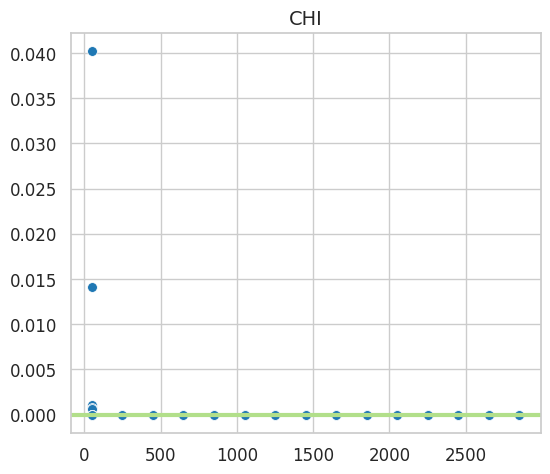

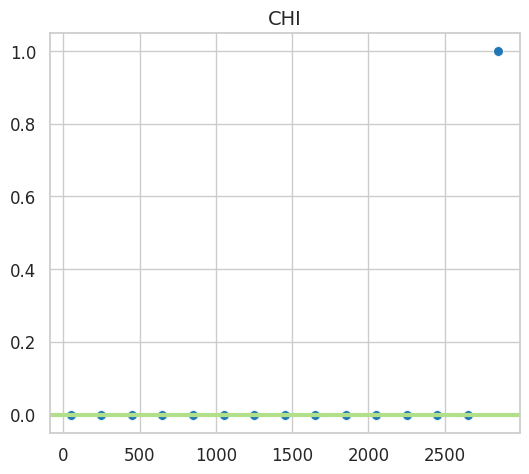

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


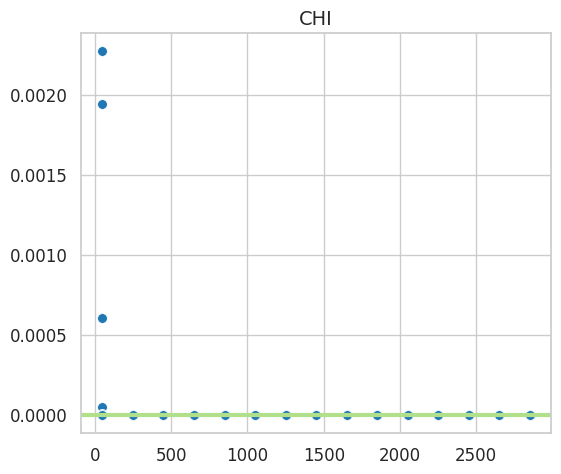

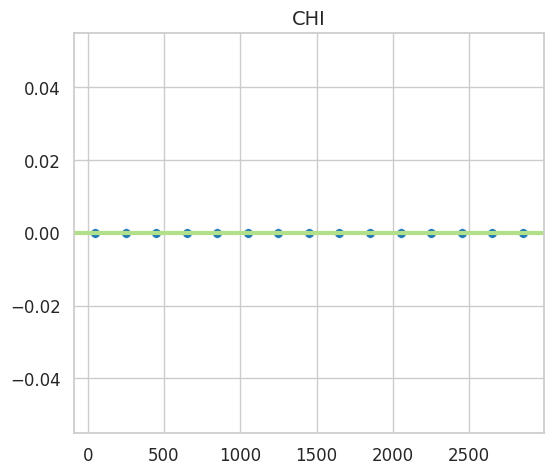

In [10]:
# ------------------ Functions to compute size imbalance experiments. (size_imbalance_experiment.py) ------------------

SMALL_SIZE = 15
matplotlib.rc('font', size=SMALL_SIZE)
matplotlib.rc('axes', titlesize=SMALL_SIZE)

sns.set_theme(style="whitegrid", font_scale=2)


def size_imbalance_sensitivity_experiment(metrics, metrics_names, corpus1, corpus2, sizes, repetitions, output_folder, corpus1_name, corpus2_name):
	distance_results = []
	source_corpora_distance = []
	for metric_idx, metric in enumerate(metrics):
		metric_distances = []
		for rep in range(repetitions):
			c1 = get_metric_dependant_data(metric, corpus1)
			c2 = get_metric_dependant_data(metric, corpus2)

			for (s, sc) in zip(sizes, reversed(sizes)):
				indices = random.sample(range(len(c1)), s)
				set1 = [c1[i] for i in indices]

				indices = random.sample(range(len(c2)), sc)
				set2 = [c2[i] for i in indices]

				indices = random.sample(range(len(c2)), s)
				set2_same_size = [c2[i] for i in indices]

				dist_complemeting = metric(set1, set2)
				dist_same_size = metric(set1, set2_same_size)

				metric_distances.append([metrics_names[metric_idx], rep, s, sc, dist_same_size, dist_complemeting])

		metric_distances_df = pd.DataFrame(metric_distances, columns=[
			'metric', 'repetition', 'size', 'size_complementing',
			'distance(same)', 'distance(comp)'
		])

		scaler_same = sklearn.preprocessing.StandardScaler().fit(metric_distances_df[['distance(same)']].values)
		scaler_comp = sklearn.preprocessing.StandardScaler().fit(metric_distances_df[['distance(comp)']].values)

		metric_distances_df['distance(same)_norm'] = scaler_same.transform(metric_distances_df[['distance(same)']].values)
		metric_distances_df['distance(comp)_norm'] = scaler_comp.transform(metric_distances_df[['distance(comp)']].values)

		distance_results.append(metric_distances_df)

		sources_distance = metric(c1, c2)
		sources_distance_norm = scaler_same.transform(np.array([[sources_distance]]))[0][0]

		source_corpora_distance.append([
			metrics_names[metric_idx], sources_distance, sources_distance_norm
		])

	size_imbalance_df = pd.concat(distance_results, ignore_index=True)
	source_corpora_distance_df = pd.DataFrame(source_corpora_distance, columns=[
		'metric', 'distance', 'distance_norm'
	])

	size_imbalance_df.to_csv(os.path.join(output_folder, corpus1_name + corpus2_name + '_size_imbalance_df.csv'), index=False)
	source_corpora_distance_df.to_csv(os.path.join(output_folder, corpus1_name + corpus2_name + '_source_corpora_distance_df.csv'), index=False)

	return size_imbalance_df, source_corpora_distance_df


def size_imbalance_robustness_measure(size_imbalance_df, source_corpora_distance_df):
	source_corpora_distance_df['size_robustness'] = np.empty(len(source_corpora_distance_df))
	source_corpora_distance_df['imbalance_robustness'] = np.empty(len(source_corpora_distance_df))
	for metric_name in np.unique(size_imbalance_df['metric']):
		metric_sizes_distance_samples = size_imbalance_df[size_imbalance_df['metric'] == metric_name]
		metric_true_sources_distance = \
		source_corpora_distance_df[source_corpora_distance_df['metric'] == metric_name]['distance'].iloc[0]

		metric_size_sens = metric_size_robustness(list(metric_sizes_distance_samples['size']),
													list(metric_sizes_distance_samples['distance(same)']),
													metric_true_sources_distance)

		metric_imbalance_sens = metric_imbalance_robustness(list(metric_sizes_distance_samples['size']),
															list(metric_sizes_distance_samples['size_complementing']),
															metric_sizes_distance_samples['distance(comp)'],
															metric_true_sources_distance)

		source_corpora_distance_df.loc[
			source_corpora_distance_df['metric'] == metric_name, 'size_robustness'] = metric_size_sens
		source_corpora_distance_df.loc[
			source_corpora_distance_df['metric'] == metric_name, 'imbalance_robustness'] = metric_imbalance_sens

	return size_imbalance_df, source_corpora_distance_df


# columns = 'distance(comp)_norm' or 'distance(same)_norm'
def plot_size_imbalance_scatter(df_distances, df_distance_corpora_all, column='distance(same)_norm'):
	# Save a palette to a variable:
	palette = sns.color_palette("Paired")
	metrics_names = np.unique(df_distances['metric'])
	x_min_max = [np.min(df_distances['size']), np.max(df_distances['size'])]
	fig, ax = plt.subplots(1, len(metrics_names), figsize=(len(metrics_names) * 5, 5))
	if len(metrics_names) == 1:
		ax = [ax]
	for i, metric in enumerate(metrics_names):
		sns.scatterplot(x='size', y=column, data=df_distances[df_distances['metric'] == metric],
						ax=ax[i], color=palette[1], s=50)
		df_metric = df_distance_corpora_all[df_distance_corpora_all['metric'] == metric]
		mean_distance = np.mean(df_metric['distance'])
		ax[i].axhline(y=mean_distance, color=palette[2], linewidth=3)
		ax[i].set_title(f'{metric}', fontsize=14)
		ax[i].set_xlabel(None)
		ax[i].set_ylabel(None)
		ax[i].tick_params(axis='x', labelsize=12)
		ax[i].tick_params(axis='y', labelsize=12)

	plt.subplots_adjust(left=0.05,
                        bottom=0.1,
                        right=0.99,
                        top=0.9,
                        wspace=0.3,
                        hspace=0.4)

	# plt.savefig('size_sens.png')
	plt.show()


N = 2900
repetitions = 10
start = 50
step = 200

output_folder = './outputCompcor/size_robustness'
os.makedirs(output_folder, exist_ok=True)
clinc, banking, atis, yahoo = load_data()
name_pair = [('clinc', 'banking'), ('atis', 'yahoo')]
for i, pair in enumerate([(clinc, banking), (atis, yahoo)]):
	size_imbalance_df, source_corpora_distance_df = size_imbalance_sensitivity_experiment(metrics, metrics_names, pair[0], pair[1],
                                                                                        	list(range(start, N+ 1, step)), repetitions, output_folder, name_pair[i][0], name_pair[i][1])

	source_corpora_distance_df = source_corpora_distance_df.sort_values(by="metric", ascending=1)

	size_imbalance_df, source_corpora_distance_df = size_imbalance_robustness_measure(size_imbalance_df, source_corpora_distance_df)
	plot_size_imbalance_scatter(size_imbalance_df, source_corpora_distance_df, column='distance(same)')
	plot_size_imbalance_scatter(size_imbalance_df, source_corpora_distance_df,column='distance(comp)')